24BAD128 - EXP 10 - Scenario 1

Dataset Loaded Successfully
   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596

Top Recommendations for User 1:
movieId
475    4.148762
423    3.339679
318    3.215664
403    3.158767
433    3.102255
Name: 1, dtype: float64

RMSE: 0.6448346789594118
MAE: 0.28156380111191764


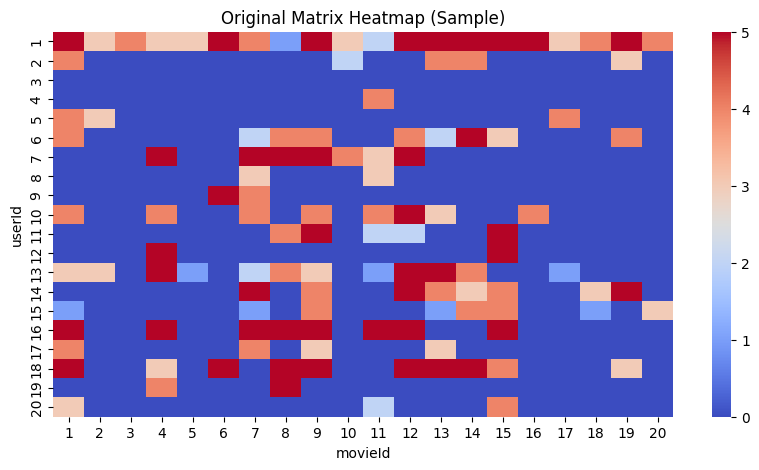

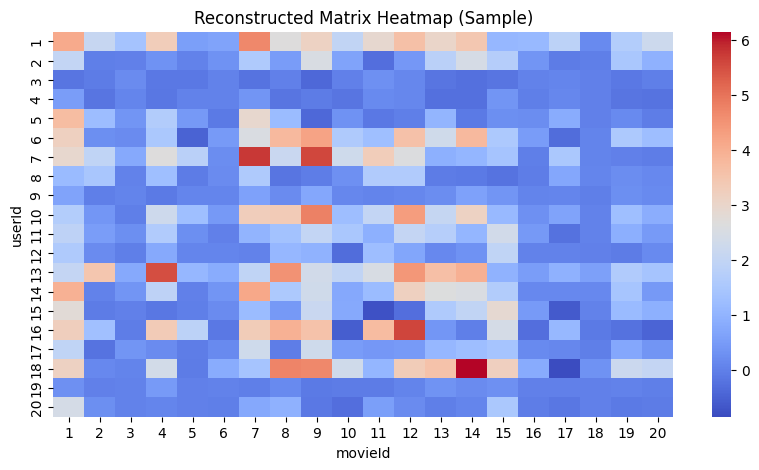

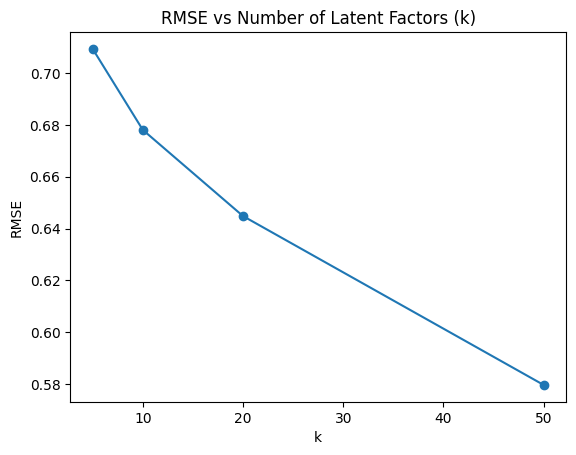

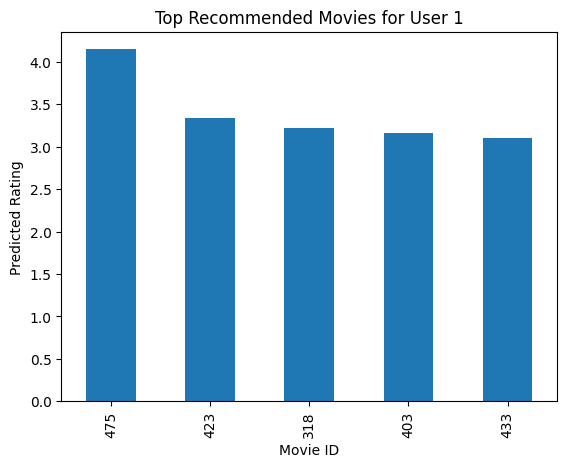

In [6]:
#24BAD128 - EXP 10 - Scenario 1
#!pip install scikit-surprise

#from google.colab import files
#uploaded = files.upload()

# Install required library (run once)
#!pip install numpy==1.26.4

print("24BAD128 - EXP 10 - Scenario 1")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

data = pd.read_csv("u.data", sep="\t",
                   names=["userId", "movieId", "rating", "timestamp"])

print("\nDataset Loaded Successfully")
print(data.head())

# Create user-item matrix
user_item_matrix = data.pivot(index='userId', columns='movieId', values='rating')

# Fill missing values with 0
matrix_filled = user_item_matrix.fillna(0)

user_means = matrix_filled.mean(axis=1)
matrix_norm = matrix_filled.sub(user_means, axis=0)

# Apply SVD
U, sigma, Vt = np.linalg.svd(matrix_norm, full_matrices=False)

k = 20

U_k = U[:, :k]
sigma_k = np.diag(sigma[:k])
Vt_k = Vt[:k, :]

reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)

reconstructed = reconstructed + user_means.values.reshape(-1, 1)

predicted_ratings = pd.DataFrame(reconstructed,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.columns)

def recommend_movies(user_id, original, predicted, n=5):
    user_row = original.loc[user_id]
    preds = predicted.loc[user_id]

    # Movies not rated
    unrated = user_row[user_row.isna()].index

    recommendations = preds[unrated].sort_values(ascending=False).head(n)
    return recommendations

print("\nTop Recommendations for User 1:")
print(recommend_movies(1, user_item_matrix, predicted_ratings, 5))

actual = matrix_filled.values
pred = predicted_ratings.values

rmse = sqrt(mean_squared_error(actual, pred))
mae = mean_absolute_error(actual, pred)

print("\nRMSE:", rmse)
print("MAE:", mae)

k_values = [5, 10, 20, 50]
rmse_list = []

for k in k_values:
    U_k = U[:, :k]
    sigma_k = np.diag(sigma[:k])
    Vt_k = Vt[:k, :]

    recon = np.dot(np.dot(U_k, sigma_k), Vt_k)
    recon = recon + user_means.values.reshape(-1, 1)

    rmse_val = sqrt(mean_squared_error(matrix_filled.values, recon))
    rmse_list.append(rmse_val)


plt.figure(figsize=(10, 5))
sns.heatmap(matrix_filled.iloc[:20, :20], cmap="coolwarm")
plt.title("Original Matrix Heatmap (Sample)")
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(predicted_ratings.iloc[:20, :20], cmap="coolwarm")
plt.title("Reconstructed Matrix Heatmap (Sample)")
plt.show()

plt.figure()
plt.plot(k_values, rmse_list, marker='o')
plt.title("RMSE vs Number of Latent Factors (k)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()

top_movies = recommend_movies(1, user_item_matrix, predicted_ratings, 5)

plt.figure()
top_movies.plot(kind='bar')
plt.title("Top Recommended Movies for User 1")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()



24BAD128 - EXP 10 - Scenario 2

Dataset Loaded Successfully
   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(



User-feature matrix shape: (943, 20)
Item-feature matrix shape: (20, 1682)

Predicted Ratings Sample:
movieId      1         2         3         4         5         6         7     \
userId                                                                          
1        4.255518  2.088239  1.426406  3.039424  0.966848  0.479364  4.975706   
2        2.260129  0.007158  0.014160  0.282828  0.084701  0.402371  1.472045   
3        0.198077  0.001735  0.042879  0.089242  0.002221  0.060573  0.144149   
4        0.651835  0.001968  0.004466  0.055929  0.060715  0.033048  0.317296   
5        3.323195  1.277656  0.296457  1.468815  0.729498  0.000000  3.206666   

movieId      8         9         10    ...      1673      1674      1675  \
userId                                 ...                                 
1        2.295917  3.171577  2.066155  ...  0.011053  0.032096  0.021676   
2        0.521715  3.096140  0.772625  ...  0.001946  0.000000  0.011960   
3        0.086057  0.1614

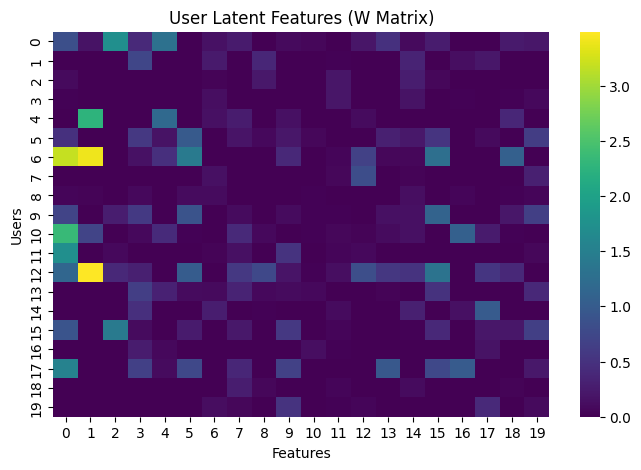

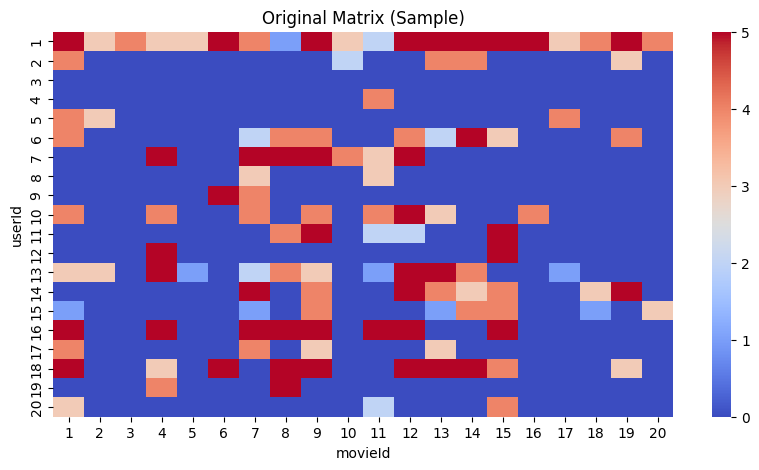

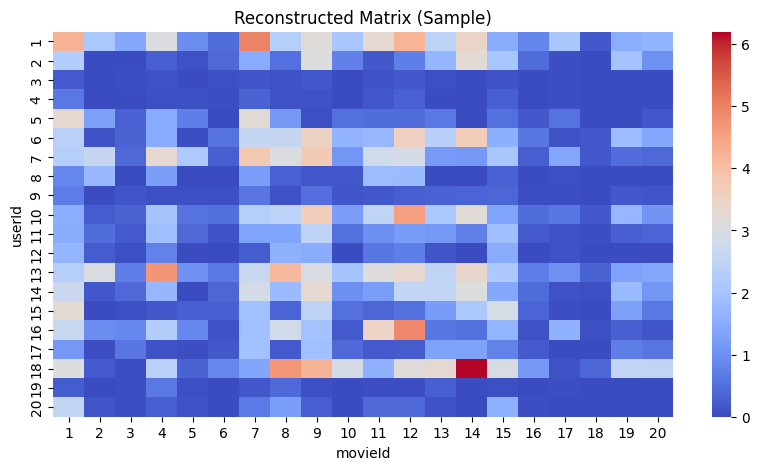

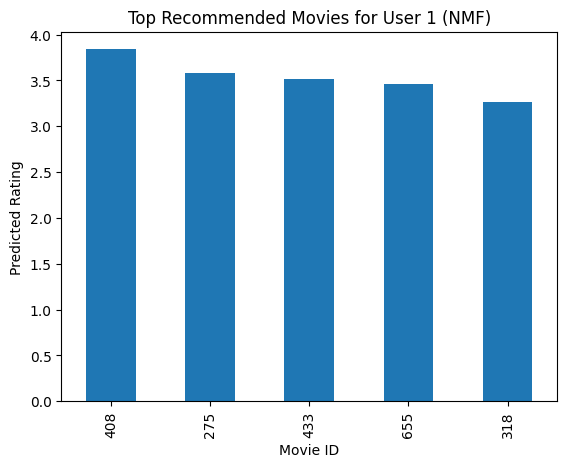

In [7]:
#24BAD128 - EXP 10 - Scenario 2
#from google.colab import files
#uploaded = files.upload()

print("24BAD128 - EXP 10 - Scenario 2")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
from math import sqrt

data = pd.read_csv("u.data", sep="\t",
                   names=["userId", "movieId", "rating", "timestamp"])

print("\nDataset Loaded Successfully")
print(data.head())


#Create User-Item Matrix
user_item_matrix = data.pivot(index='userId', columns='movieId', values='rating')

#Handle Missing Values
matrix_filled = user_item_matrix.fillna(0)

#Apply NMF Model
nmf_model = NMF(n_components=20, init='random', random_state=42, max_iter=200)

W = nmf_model.fit_transform(matrix_filled)   # User-feature matrix
H = nmf_model.components_                    # Item-feature matrix

print("\nUser-feature matrix shape:", W.shape)
print("Item-feature matrix shape:", H.shape)

#Reconstruct Matrix
reconstructed = np.dot(W, H)

# Convert to DataFrame
predicted_ratings = pd.DataFrame(reconstructed,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.columns)

#Predict Missing Values
print("\nPredicted Ratings Sample:")
print(predicted_ratings.head())

#Top-N Recommendations

def recommend_movies(user_id, original, predicted, n=5):
    user_row = original.loc[user_id]
    preds = predicted.loc[user_id]

    # Movies not rated
    unrated = user_row[user_row.isna()].index

    recommendations = preds[unrated].sort_values(ascending=False).head(n)
    return recommendations

print("\nTop Recommendations for User 1:")
top_movies = recommend_movies(1, user_item_matrix, predicted_ratings, 5)
print(top_movies)

#EVALUATION METRICS

# RMSE
rmse = sqrt(mean_squared_error(matrix_filled.values, predicted_ratings.values))
print("\nRMSE:", rmse)

# Precision@K and Recall@K
def precision_recall_at_k(original, predicted, k=5, threshold=3.5):
    precisions = []
    recalls = []

    for user in original.index:
        actual = original.loc[user]
        preds = predicted.loc[user]

        # Relevant items
        relevant = actual[actual >= threshold].index

        # Top K predictions
        top_k = preds.sort_values(ascending=False).head(k).index

        # True positives
        tp = len(set(top_k) & set(relevant))

        precision = tp / k if k > 0 else 0
        recall = tp / len(relevant) if len(relevant) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

precision, recall = precision_recall_at_k(user_item_matrix.fillna(0), predicted_ratings)

print("Precision@K:", precision)
print("Recall@K:", recall)

#Compare Sparsity

sparsity = 1.0 - np.count_nonzero(matrix_filled) / matrix_filled.size
print("\nSparsity of dataset:", sparsity)

#Latent Features
plt.figure(figsize=(8, 5))
sns.heatmap(W[:20, :], cmap='viridis')
plt.title("User Latent Features (W Matrix)")
plt.xlabel("Features")
plt.ylabel("Users")
plt.show()

#Reconstruction Comparison
plt.figure(figsize=(10, 5))
sns.heatmap(matrix_filled.iloc[:20, :20], cmap='coolwarm')
plt.title("Original Matrix (Sample)")
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(predicted_ratings.iloc[:20, :20], cmap='coolwarm')
plt.title("Reconstructed Matrix (Sample)")
plt.show()

#Recommendation Ranking
plt.figure()
top_movies.plot(kind='bar')
plt.title("Top Recommended Movies for User 1 (NMF)")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()